In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from dataloader import get_data
from sklearn.preprocessing import MinMaxScaler

In [26]:
df = pd.read_csv('sdi_1_24.csv')

df.columns = ['S2K_item_1', 'S2K_item_2', 'S2K_item_3', 'S2K_item_4', 'S2K_item_5',
       'S2K_item_6', 'S2K_item_7', 'S2K_item_8', 'S2K_item_9', 'S2K_item_10',
       'S2K_item_11', 'S2K_item_12', 'S2K_item_13', 'S2K_item_14',
       'S2K_item_15', 'S2K_item_16', 'S2K_item_17', 'S2K_item_18',
       'S2K_item_19', 'S2K_item_20', 'S2K_item_21', 'S2K_item_22',
       'S2K_item_23', 'S2K_item_24']

In [27]:
df = df.astype('float32')
dataset, dataloader = get_data(df)

In [28]:
input_dim = 100
output_dim = dataset.shape()[1]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [29]:
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, output_dim),
            nn.ReLU(True)
        )

    def forward(self, x):
        return self.model(x)


In [30]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [31]:
generator = Generator(input_dim, output_dim).to(device)
discriminator = Discriminator(output_dim).to(device)


print(f"Generator model initialized with input_dim={input_dim} and moved to {device}.")
print(f"Discriminator model initialized and moved to {device}.")


Generator model initialized with input_dim=100 and moved to cuda:0.
Discriminator model initialized and moved to cuda:0.


In [32]:
criterion = nn.BCELoss()
lr = 2e-5

optimizer_g = optim.Adam(generator.parameters(), lr=lr)
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr)

num_epochs = 50
batch_size = 64

In [33]:
for epoch in range(num_epochs):
    for i, (real_samples, _) in enumerate(dataloader):
        batch_size = real_samples.size(0)
        real_samples = real_samples.to(device)


        # Adversarial ground truths
        valid = torch.ones(batch_size, 1, requires_grad=False).to(device)
        fake = torch.zeros(batch_size, 1, requires_grad=False).to(device)


        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_d.zero_grad()

        # Noise
        z = torch.randn(batch_size, input_dim).to(device)

        # Batch Generation
        gen_samples = generator(z)

        # Loss 
        real_loss = criterion(discriminator(real_samples), valid)
        fake_loss = criterion(discriminator(gen_samples.detach()), fake)
        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_d.step()

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_g.zero_grad()

        # Loss
        g_loss = criterion(discriminator(gen_samples), valid)

        g_loss.backward()
        optimizer_g.step()


        if i % 100 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] [Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]")

[Epoch 0/50] [Batch 0/38] [D loss: 1.3867136240005493] [G loss: 0.6670260429382324]
[Epoch 1/50] [Batch 0/38] [D loss: 1.3791654109954834] [G loss: 0.6746293902397156]
[Epoch 2/50] [Batch 0/38] [D loss: 1.3768930435180664] [G loss: 0.6799089312553406]
[Epoch 3/50] [Batch 0/38] [D loss: 1.3763256072998047] [G loss: 0.6820853352546692]
[Epoch 4/50] [Batch 0/38] [D loss: 1.3626388311386108] [G loss: 0.6955527067184448]
[Epoch 5/50] [Batch 0/38] [D loss: 1.32896888256073] [G loss: 0.7134381532669067]
[Epoch 6/50] [Batch 0/38] [D loss: 1.3445287942886353] [G loss: 0.6909071207046509]
[Epoch 7/50] [Batch 0/38] [D loss: 1.3774588108062744] [G loss: 0.6787458658218384]
[Epoch 8/50] [Batch 0/38] [D loss: 1.35439932346344] [G loss: 0.6992042660713196]
[Epoch 9/50] [Batch 0/38] [D loss: 1.3355646133422852] [G loss: 0.7291821241378784]
[Epoch 10/50] [Batch 0/38] [D loss: 1.2740191221237183] [G loss: 0.7526527643203735]
[Epoch 11/50] [Batch 0/38] [D loss: 1.2883906364440918] [G loss: 0.735430657863

In [34]:
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')

In [35]:
num_samples = 2400
noise_vectors = torch.randn(num_samples, input_dim).to(device)

with torch.no_grad():
    gen_samples = generator(noise_vectors)

gen_samples = gen_samples.cpu().numpy()
gen_df = pd.DataFrame(gen_samples)
gen_df.columns = df.columns

In [36]:
cols = ['S2K_item_1', 'S2K_item_2', 'S2K_item_3', 'S2K_item_4', 'S2K_item_5',
       'S2K_item_6', 'S2K_item_7', 'S2K_item_8', 'S2K_item_9', 'S2K_item_10',
       'S2K_item_11', 'S2K_item_12', 'S2K_item_13', 'S2K_item_14',
       'S2K_item_15', 'S2K_item_16', 'S2K_item_17', 'S2K_item_18',
       'S2K_item_19', 'S2K_item_20', 'S2K_item_21', 'S2K_item_22',
       'S2K_item_23', 'S2K_item_24']
ranges = []

for col in cols:
    ranges.append(list(gen_df[col].unique()))
    print(f'Column: {col} - {gen_df[col].unique()}')

Column: S2K_item_1 - [0.         0.00446395 0.00148458 0.00338576 0.0014713  0.00280524
 0.00031126 0.00392776 0.00839558 0.00108637 0.00375863 0.0061853
 0.00110416]
Column: S2K_item_2 - [0.]
Column: S2K_item_3 - [0.]
Column: S2K_item_4 - [0.         0.00258331 0.00158696 0.0076519  0.00472705]
Column: S2K_item_5 - [0.]
Column: S2K_item_6 - [0.         0.00636166 0.00592017 0.00010133 0.00977101 0.00082521
 0.00100235 0.00205692 0.00791647 0.004133   0.00713676 0.00866486
 0.00727757 0.00771686 0.00739073 0.02888588 0.00344297 0.00389627
 0.00107537 0.00593667 0.01011595 0.003712   0.00016378 0.01066087
 0.01027913 0.00117098 0.0081806  0.00023752 0.00303219 0.00486871
 0.00800456]
Column: S2K_item_7 - [0.         0.00179316 0.00241574]
Column: S2K_item_8 - [0.         0.00207384]
Column: S2K_item_9 - [4.85448055e-02 0.00000000e+00 9.22916457e-03 7.36536533e-02
 1.03791524e-02 1.63123030e-02 3.00340354e-03 7.03915954e-03
 2.53327936e-03 9.04718116e-02 1.21003613e-02 2.68412828e-02
 3.

In [37]:
gen_df = gen_df.apply(lambda x: np.ceil(x))

In [38]:
gen_df.to_csv('gen_sdi_1.csv', index=False)

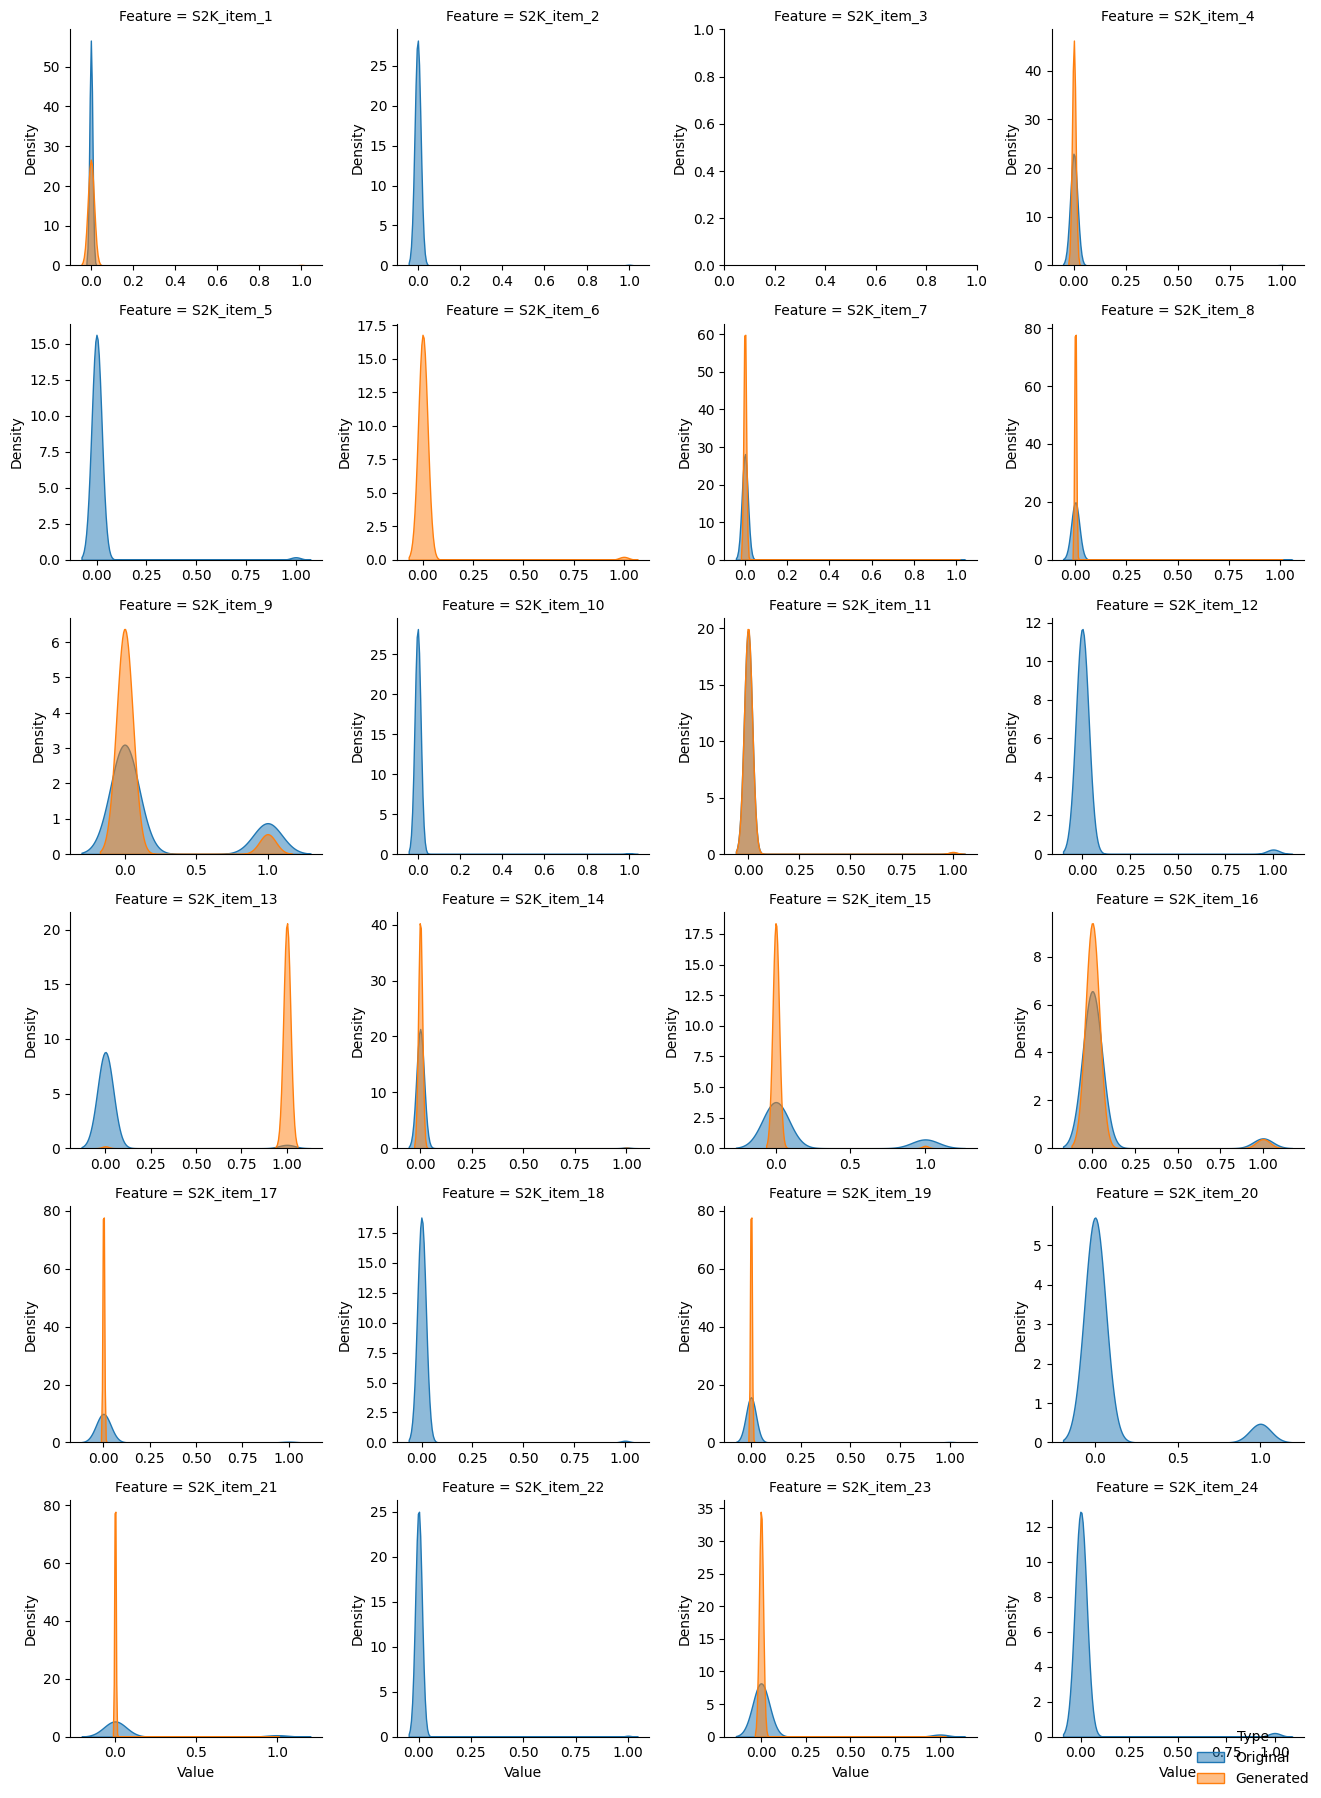

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Type'] = 'Original'
gen_df['Type'] = 'Generated'

combined_df = pd.concat([df, gen_df])

melted_df = combined_df.melt(id_vars='Type', var_name='Feature', value_name='Value')

g = sns.FacetGrid(melted_df, col="Feature", hue="Type", col_wrap=4, sharex=False, sharey=False, height=3)
g.map(sns.kdeplot, 'Value', fill=True, common_norm=True, alpha=0.5,warn_singular=False)
g.add_legend(loc='lower right')

plt.tight_layout()
plt.show()
